In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pj = ['Graphein', 'PDBGraphStore']

In [4]:
graphein = pj[0]+'_notebooks'
pdb_store = pj[1]+'_notebooks'

In [5]:
print(graphein)

Graphein_notebooks


In [6]:
nb = ['baseline', 'tdc']

g_nb = graphein+'/'+nb[1]+'_memory.csv'
p_nb = pdb_store+'/'+nb[1]+'_memory.csv'

print(g_nb)
print(p_nb)

Graphein_notebooks/tdc_memory.csv
PDBGraphStore_notebooks/tdc_memory.csv


In [7]:
# Caminho para o arquivo
file1 = g_nb
file2 = p_nb

print(file1)
print(file2)

Graphein_notebooks/tdc_memory.csv
PDBGraphStore_notebooks/tdc_memory.csv


In [8]:
df1 = pd.read_csv(
    file1,
    header=None,
    names=["timestamp", "memory"]
)

df2 = pd.read_csv(
    file2,
    header=None,
    names=["timestamp", "memory"]
)

In [9]:
# Extrai apenas a memória utilizada
extracted1 = df1["memory"].str.extract(r"^([\d.]+)(MiB|GiB)")
extracted2 = df2["memory"].str.extract(r"^([\d.]+)(MiB|GiB)")

df1["used_gib"] = extracted1[0].astype(float)
df1.loc[extracted1[1] == "MiB", "used_gib"] /= 1024

df2["used_gib"] = extracted2[0].astype(float)
df2.loc[extracted2[1] == "MiB", "used_gib"] /= 1024


print(f"\nMemoria medida pelo workflow: \nPDBGS: {max(df2['used_gib'])}GB\nGraphein:{max(df1['used_gib'])}GB\n")

ratio_max = 1 - (max(df2['used_gib'])/ max(df1['used_gib']))
ratio_dsa = 1 - (3.403/4.805)

print(f'{(ratio_max * 100):.2f}% less memory at the maximum point')

print(f'\n\ntamanho das estruturas: \nPDBGS: {3.403}GB\nGraphein:{4.805}GB')
print(f'{(ratio_dsa * 100):.2f}% less memory at the maximum point')


Memoria medida pelo workflow: 
PDBGS: 6.096GB
Graphein:7.31GB

16.61% less memory at the maximum point


tamanho das estruturas: 
PDBGS: 3.403GB
Graphein:4.805GB
29.18% less memory at the maximum point


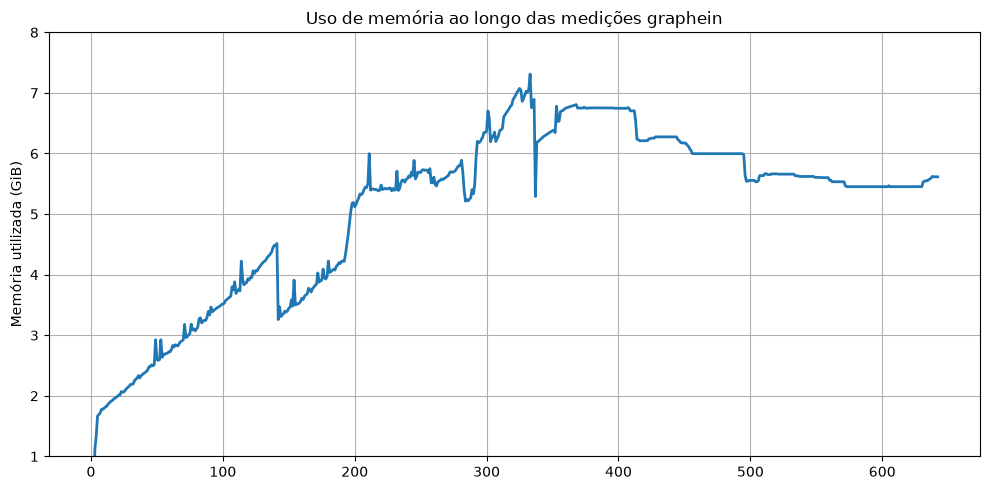

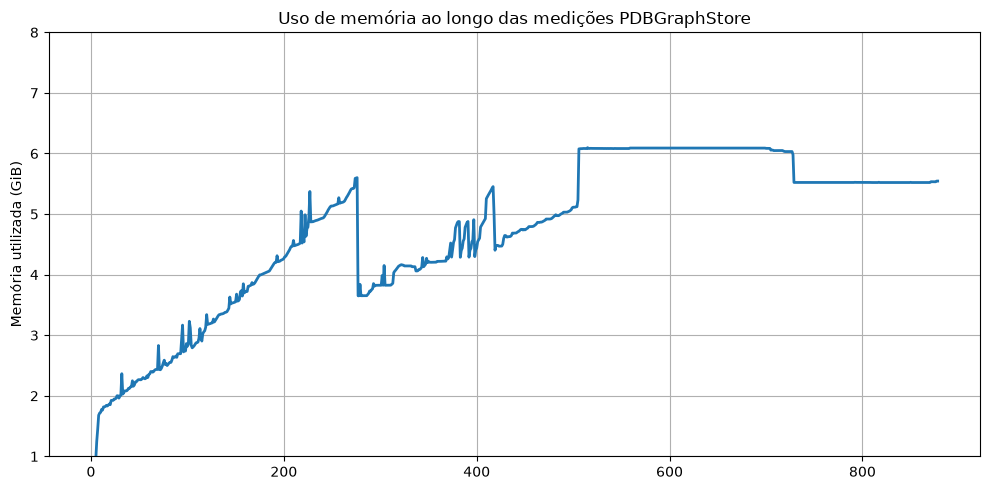

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df1["used_gib"], linewidth=2)

plt.ylim(1, 8)

plt.title("Uso de memória ao longo das medições graphein")
plt.ylabel("Memória utilizada (GiB)")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df2["used_gib"], linewidth=2)

plt.ylim(1, 8)

plt.title("Uso de memória ao longo das medições PDBGraphStore")
plt.ylabel("Memória utilizada (GiB)")
plt.grid(True)

plt.tight_layout()
plt.show()